# Base de dades 2023

Aquest notebook utilitza els conjunts de dades del 2023 proporcionats per la competició IPIN. Amb aquests s'ha seguit els següents passos:

1. Anàlisi exploratòria i reducció manual de la dimensionalitat
2. Experiments amb models d'aprenentatge automàtic

In [1]:
# llibreries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
# Detectar si s'executa a Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# A Colab cal clonar el repositori públic per tenir accés a les dades.
# En local s'assumeix que el notebook s'executa des de l'arrel del repositori clonat.
if IN_COLAB:
    if not os.path.isdir('indoor-location'):
        !git clone https://github.com/nuriacanals3/indoor-location.git
    os.chdir('indoor-location')

In [3]:
# Carregar les dades

# Definir la ruta base de les dades
base_path = './Dades/2023/'

# Train
df_train_rss_2023 = pd.read_csv(os.path.join(base_path, 'ipin2023_trainrss.csv'), header=None)
df_train_fl_2023  = pd.read_csv(os.path.join(base_path, 'ipin2023_trainflr.csv'), header=None)

# Validate
df_val_rss_2023 = pd.read_csv(os.path.join(base_path, 'ipin2023_validrss.csv'), header=None)
df_val_fl_2023  = pd.read_csv(os.path.join(base_path, 'ipin2023_validflr.csv'), header=None)

# Test
df_test_rss_2023 = pd.read_csv(os.path.join(base_path, 'ipin2023_ctestreducedrss.csv'), header=None)
df_test_fl_2023  = pd.read_csv(os.path.join(base_path, 'ipin2023_ctestreducedfloor.csv'), header=None)

## Anàlisi exploratòria i reducció manual de la dimensionalitat
A continuació es fa un anàlisi de les dades i una reducció manual de la dimensionalitat del conjunt d'entrenament utilitzant els següents dataframes:
*   df_train_rss_2023
*   df_train_fl_2023



In [4]:
# Dimensionalitat de les dades
df_train_rss_2023.shape

(3275, 310)

In [ ]:
# Anomenar columnes APs
nous_noms = [f"AP_{i}" for i in range(310)]
df_train_rss_2023.columns = nous_noms
df_val_rss_2023.columns = nous_noms
df_test_rss_2023.columns = nous_noms

# Juntar el dataset de potències amb el de planta
df_train_2023 = pd.concat([df_train_rss_2023, df_train_fl_2023], axis=1)

# Reanomenar la columna objectiu
df_train_2023 = df_train_2023.rename(columns={0: 'Pis'})

df_train_2023.head()

,AP_0,AP_1,AP_2,AP_3,AP_4,AP_5,AP_6,AP_7,AP_8,AP_9,...,AP_301,AP_302,AP_303,AP_304,AP_305,AP_306,AP_307,AP_308,AP_309,Pis
0,-60,-89,-84,-86,-87,100,100,100,-72,100,...,100,100,100,100,100,100,100,100,100,0
1,-64,100,-81,100,-83,100,-88,100,100,100,...,100,100,100,100,100,100,100,100,100,0
2,-62,100,-87,-90,-91,100,-80,100,100,100,...,100,100,100,100,100,100,100,100,100,0
3,-56,-86,-82,-85,-86,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,0
4,-63,-90,-82,-80,-81,100,100,100,-68,-83,...,100,100,100,100,100,100,100,100,100,0


In [ ]:
# Canviar els valors 100 per a NaN per analitzar les dades
df_train_2023 = df_train_2023.replace(100, np.nan)

In [ ]:
# Rang potències
rss_min_global = df_train_2023.drop(columns=['Pis']).min().min()
rss_max_global = df_train_2023.drop(columns=['Pis']).max().max()

print(f"Senyal més feble global: {rss_min_global} dBm")
print(f"Senyal més forta global: {rss_max_global} dBm")

Senyal més feble global: -99.0 dBm
Senyal més forta global: -38.0 dBm


In [ ]:
# Columna objectiu
plantes = df_train_2023['Pis'].unique()

print(f"L'edifici està composat per {len(plantes)} plantes: {plantes.tolist()}")

L'edifici està composat per 3 plantes: [0, -2, -1]


### Pas 1 - Reducció de la dimensionalitat:

Eliminar els punts d'accés (AP) que no reben cap senyal. En aquest cas s'ha passat d'un conjunt amb 310 punts d'accés a un reduït de 226.

In [ ]:
# Eliminar les columnes on tots els valors siguin NaN
df_train_2023_reduced = df_train_2023.dropna(axis=1, how='all')

print(f"Columnes originals: {df_train_2023.shape[1]}")
print(f"Columnes útils: {df_train_2023_reduced.shape[1]}")

Columnes originals: 311
Columnes útils: 227


### Pas 2 - Reducció de la dimensionalitat:

1. Anàlisi dels punts d'accés (APs) amb molt baixa latència.
2. Anàlisi de la freqüència d'aparició dels punts d'accés per planta.
3. Anàlisi de la freqüència de les potències més fortes.
4. Eliminar els APs amb una detecció menor al 5% de registres i un RSS major a -80.


**1. Anàlisi dels APs amb molt baixa latència:**

In [ ]:
# Comptar quants cops apareix NaN a cada columna
aps = df_train_2023_reduced.drop(columns=['Pis'])
comptador_no_senyal = aps.isna().sum() # Índex = nom columna (AP), Valor = comptador

# Calcular el percentatge d'absència de senyal
percentatge_no_senyal = (comptador_no_senyal / len(aps)) * 100

# Unir les dades per visualitzar-les
df_analisi_buits = pd.DataFrame({
    'Num_No_Senyal': comptador_no_senyal,
    'Percentatge_Buits': percentatge_no_senyal
})

# Ordenar descendentment per percentatge de buits
df_analisi_buits = df_analisi_buits.sort_values(by='Percentatge_Buits', ascending=False)

# Mostrar els 20 primers
print("Top 20 punts d'accés Wi-Fi menys utilitzats:")
print(df_analisi_buits.head(20))

Top 20 punts d'accés Wi-Fi menys utilitzats:
        Num_No_Senyal  Percentatge_Buits
AP_35            3274          99.969466
AP_30            3274          99.969466
AP_66            3274          99.969466
AP_71            3274          99.969466
AP_58            3274          99.969466
AP_60            3274          99.969466
AP_49            3274          99.969466
AP_46            3274          99.969466
AP_41            3274          99.969466
AP_40            3274          99.969466
AP_255           3274          99.969466
AP_264           3274          99.969466
AP_288           3274          99.969466
AP_292           3274          99.969466
AP_285           3274          99.969466
AP_304           3274          99.969466
AP_306           3274          99.969466
AP_309           3274          99.969466
AP_294           3274          99.969466
AP_296           3274          99.969466


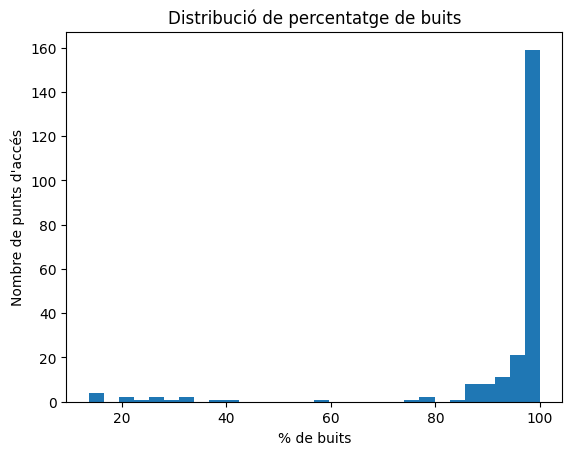

In [ ]:
# Histograma per veure la distribució global
plt.figure()
plt.hist(df_analisi_buits['Percentatge_Buits'], bins=30)
plt.xlabel("% de buits")
plt.ylabel("Nombre de punts d'accés")
plt.title("Distribució de percentatge de buits")
plt.show()


In [ ]:
# Mostrar el total que passen el 99% de buits
punts_mes_99 = df_analisi_buits[df_analisi_buits['Percentatge_Buits'] > 99]
print(f"Punts Wi-Fi amb més del 99% buits: {len(punts_mes_99)} de {aps.shape[1]}")
print(punts_mes_99)

Punts Wi-Fi amb més del 99% buits: 111 de 226
        Num_No_Senyal  Percentatge_Buits
AP_35            3274          99.969466
AP_30            3274          99.969466
AP_66            3274          99.969466
AP_71            3274          99.969466
AP_58            3274          99.969466
...               ...                ...
AP_174           3247          99.145038
AP_163           3246          99.114504
AP_223           3244          99.053435
AP_195           3244          99.053435
AP_138           3243          99.022901

[111 rows x 2 columns]


Aquest anàlisi mostra que existeixen molts punts d'accés on pràcticament tots els seus registres són buits. A continuació s'analitza en profunditat la freqüència de detecció de cada punt d'accés i la potència màxima.

**2. Anàlisi de la freqüència d'aparició dels APs en cada planta:**

Heatmap per veure quantes vegades es detecta cada AP en cada planta.

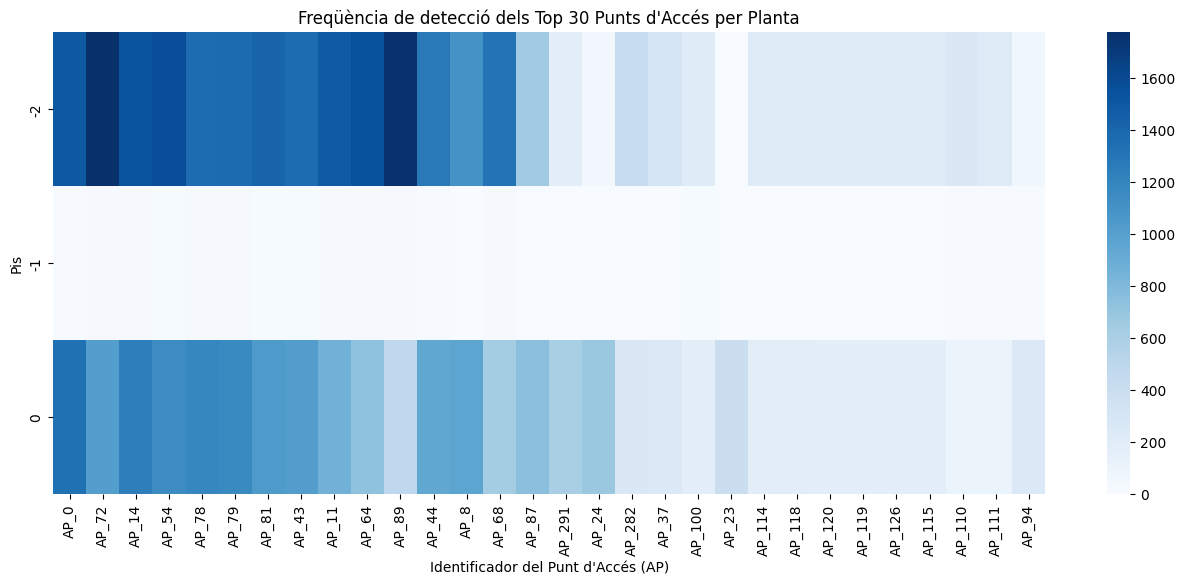

In [ ]:
# Calcular la freqüència: quantes vegades es veu cada AP a cada pis
freq_ap_pis = df_train_2023_reduced.groupby('Pis').count()

# Visualització: filtrar els 30 que més apareixen per veure-ho més clar
top_30_aps = freq_ap_pis.sum().nlargest(30).index

plt.figure(figsize=(16, 6))
sns.heatmap(freq_ap_pis[top_30_aps], cmap='Blues', annot=False)
plt.title('Freqüència de detecció dels Top 30 Punts d\'Accés per Planta')
plt.ylabel('Pis')
plt.xlabel('Identificador del Punt d\'Accés (AP)')
plt.show()



**3. Anàlisi de la freqüència de les potències més fortes:**

Histograma de freqüències dels valors més potents de cada registre de manera global i per planta.

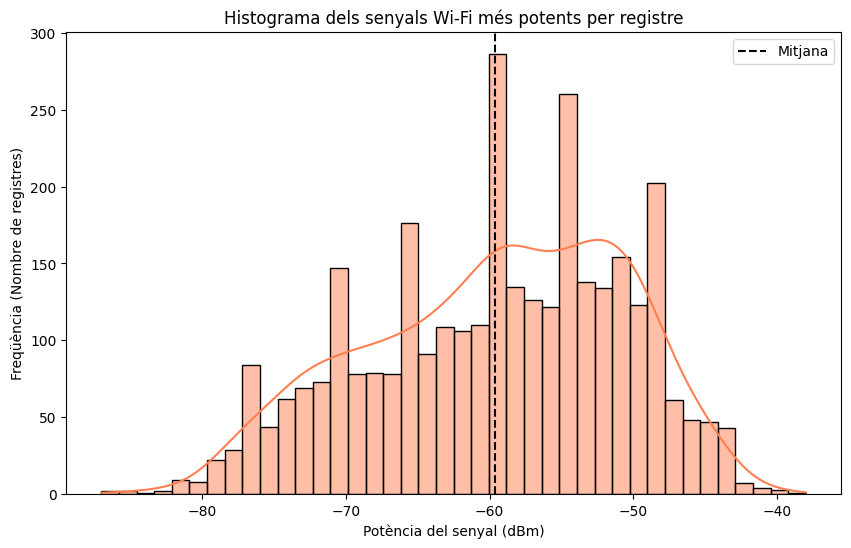

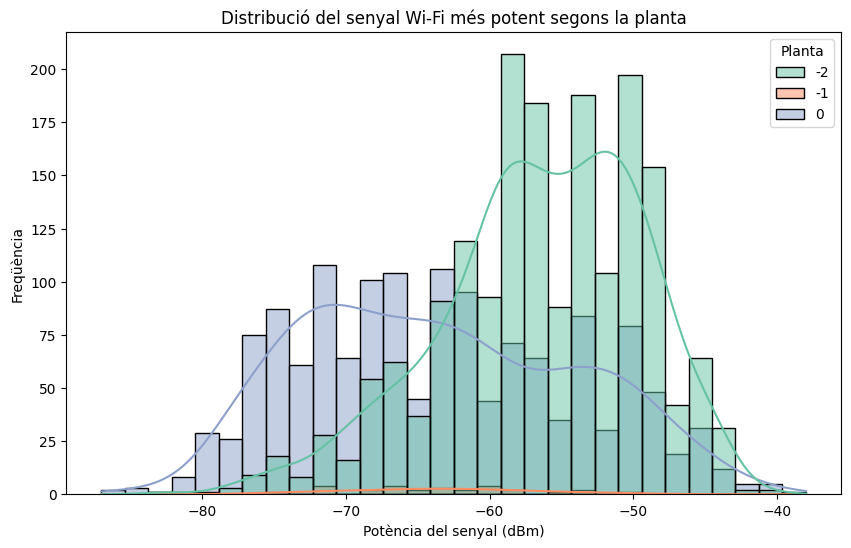

In [ ]:
# Separar la columna objectiu
pisos = df_train_2023_reduced.iloc[:, -1]
senyals = df_train_2023_reduced.iloc[:, :-1]

# Trobar el senyal més potent per a cada registre
valors_mes_potents = senyals.max(axis=1)

# Histograma global
plt.figure(figsize=(10, 6))
sns.histplot(valors_mes_potents, bins=40, color='coral', kde=True)
plt.title('Histograma dels senyals Wi-Fi més potents per registre')
plt.xlabel('Potència del senyal (dBm)')
plt.ylabel('Freqüència (Nombre de registres)')
plt.axvline(valors_mes_potents.mean(), color='black', linestyle='dashed', linewidth=1.5, label='Mitjana')
plt.legend()
plt.show()

# Histograma per pis
df_plot = senyals.copy()
df_plot['Planta'] = pisos
df_plot['max_signal'] = valors_mes_potents

plt.figure(figsize=(10, 6))
sns.histplot(data=df_plot, x='max_signal', hue='Planta', kde=True, bins=30, palette='Set2')
plt.title('Distribució del senyal Wi-Fi més potent segons la planta')
plt.xlabel('Potència del senyal (dBm)')
plt.ylabel('Freqüència')
plt.show()



**4. Eliminar els APs amb una detecció menor al 5% de registres i un RSS major a -80:**

In [ ]:
# Separar variable objectiu
aps = df_train_2023_reduced.iloc[:, :-1]
planta = df_train_2023_reduced.iloc[:, -1]

# Calcular els APs possibles a eliminar
stats_signal = pd.DataFrame({
    "count": aps.count(),
    "max": aps.max()
})

# Llindars
perc_detectats = 0.05
potencia_max = -80

# Identificar els APs a eliminar
aps_eliminar = stats_signal[
    (stats_signal['count'] < len(aps)*perc_detectats) &
    (stats_signal['max'] < potencia_max)
]

# Eliminar i ajuntar la variable planta
aps_reduced  = aps.drop(columns=aps_eliminar.index)
df_train_2023_reduced_2 = pd.concat([aps_reduced, planta], axis=1)

print(f"{len(aps_eliminar)} APs eliminats: {aps_eliminar.index.to_list()} \n {aps_eliminar}")
print(f"Dimensions originals: {df_train_2023_reduced.shape[1]}")
print(f"Dimensions noves: {df_train_2023_reduced_2.shape[1]}")

134 APs eliminats: ['AP_7', 'AP_9', 'AP_10', 'AP_12', 'AP_13', 'AP_15', 'AP_16', 'AP_17', 'AP_18', 'AP_20', 'AP_21', 'AP_22', 'AP_30', 'AP_33', 'AP_34', 'AP_35', 'AP_36', 'AP_40', 'AP_41', 'AP_46', 'AP_47', 'AP_48', 'AP_49', 'AP_50', 'AP_51', 'AP_55', 'AP_58', 'AP_60', 'AP_61', 'AP_66', 'AP_67', 'AP_70', 'AP_71', 'AP_83', 'AP_101', 'AP_104', 'AP_109', 'AP_113', 'AP_116', 'AP_121', 'AP_122', 'AP_123', 'AP_125', 'AP_127', 'AP_128', 'AP_131', 'AP_132', 'AP_133', 'AP_134', 'AP_135', 'AP_138', 'AP_139', 'AP_140', 'AP_141', 'AP_144', 'AP_145', 'AP_150', 'AP_151', 'AP_153', 'AP_154', 'AP_155', 'AP_164', 'AP_165', 'AP_166', 'AP_167', 'AP_168', 'AP_169', 'AP_171', 'AP_172', 'AP_175', 'AP_176', 'AP_182', 'AP_184', 'AP_185', 'AP_186', 'AP_187', 'AP_189', 'AP_190', 'AP_191', 'AP_192', 'AP_193', 'AP_195', 'AP_197', 'AP_200', 'AP_208', 'AP_209', 'AP_210', 'AP_211', 'AP_213', 'AP_214', 'AP_222', 'AP_227', 'AP_233', 'AP_234', 'AP_238', 'AP_253', 'AP_254', 'AP_255', 'AP_258', 'AP_259', 'AP_260', 'AP_26

En aquest pas s'ha eliminat 134 APs, passant de 226 a 93.

### Pas 3 - Reducció de la dimensionalitat:

1. Anàlisi de les correlacions entre APs.
2. Eliminar APs altament correlacionats (Redundància).

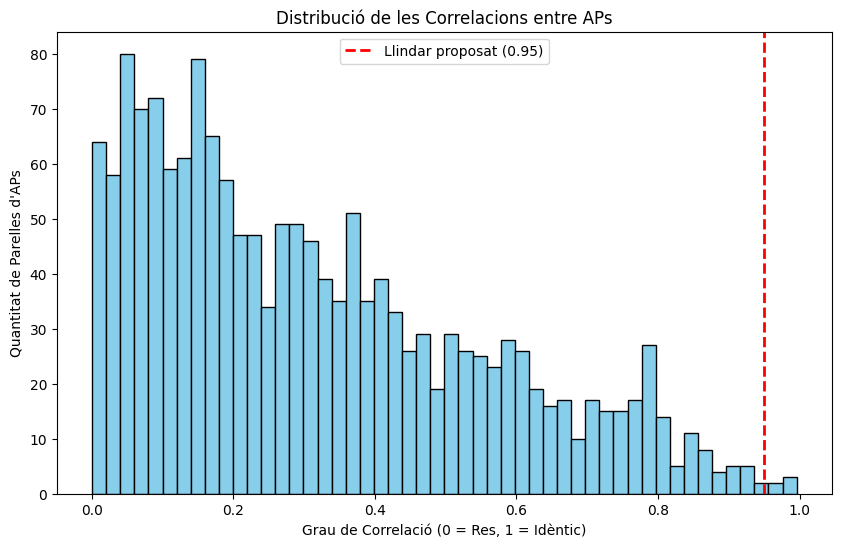

In [ ]:
# Almenys han de tenir 30 mostres compartides per calcular la correlació
minim_mostres_compartides = 30

# Calcular la matriu de correlació
corr_matrix = df_train_2023_reduced_2.drop(columns=['Pis']).corr(min_periods=minim_mostres_compartides).abs()

# Seleccionar el triangle superior de la matriu per evaluar només 1 cop cada parella
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Crear histograma
upper_values = upper.stack()
plt.figure(figsize=(10, 6))
plt.hist(upper_values, bins=50, color='skyblue', edgecolor='black')

# Dibuixar una línia vermella on llindar (0.95)
plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Llindar proposat (0.95)')

plt.title('Distribució de les Correlacions entre APs')
plt.xlabel('Grau de Correlació (0 = Res, 1 = Idèntic)')
plt.ylabel('Quantitat de Parelles d\'APs')
plt.legend()
plt.show()

La majoria de punts d'accés no estan altament correlacionats, és a dir, aporten informació diferent.

In [ ]:
# Definir llindar (si dos APs s'assemble més d'aquest %, s'elimina un)
llindar = 0.95

# Identificar les columnes a eliminar
to_drop = [column for column in upper.columns if any(upper[column] > llindar)]

print(f"Amb un mínim de {minim_mostres_compartides} mostres, s'han detectat {len(to_drop)} APs altament correlacionats (llindar > {llindar})")

# Veure quins APs s'han eliminat
print("Columnes a eliminar:", to_drop)

Amb un mínim de 30 mostres, s'han detectat 6 APs altament correlacionats (llindar > 0.95)
Columnes a eliminar: ['AP_79', 'AP_81', 'AP_106', 'AP_142', 'AP_216', 'AP_221']


S'han detectat 6 parells altament correlacionats. Generant gràfiques...

--------------------------------------------------


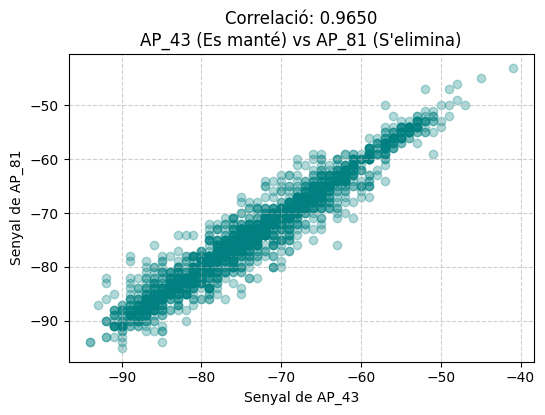

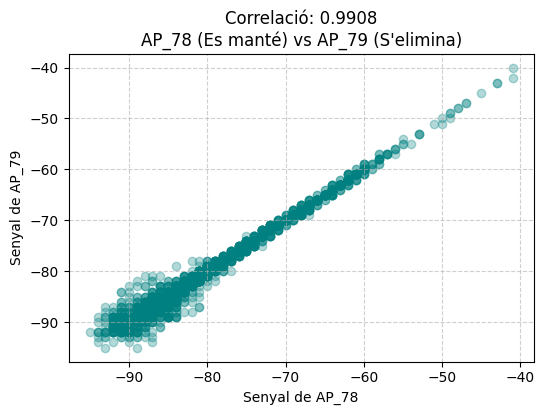

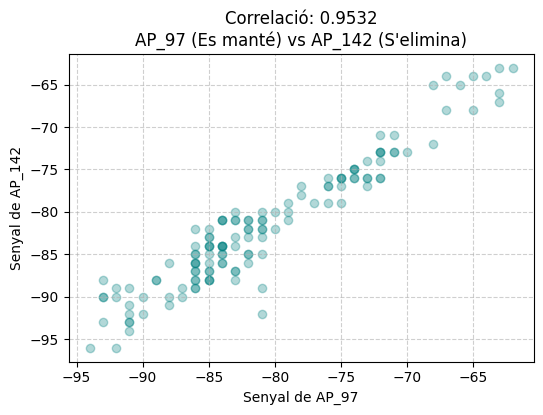

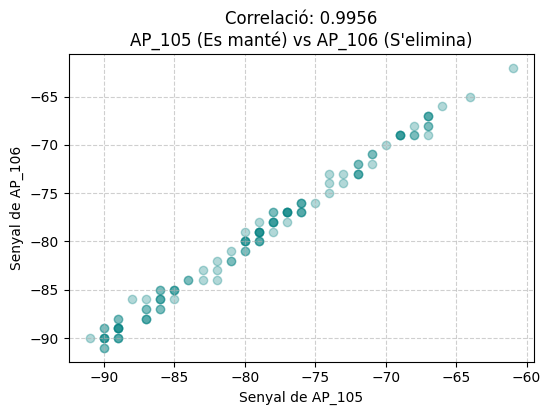

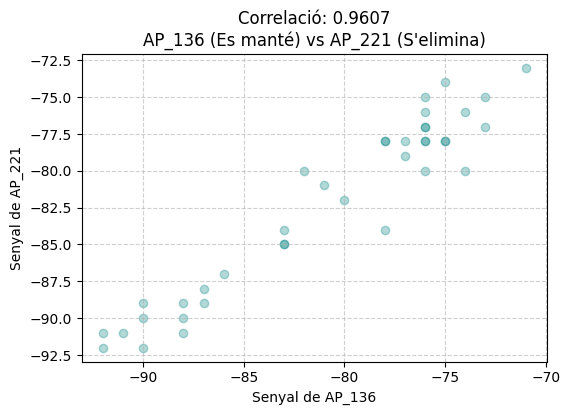

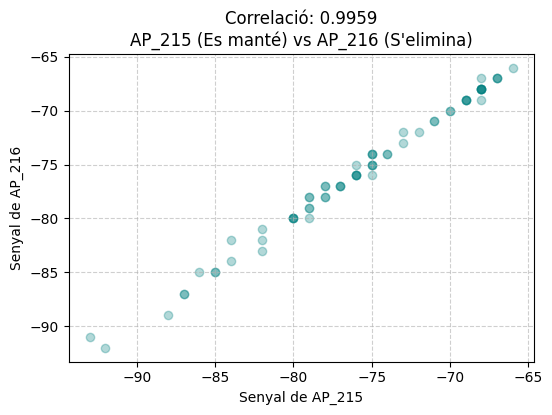

In [ ]:
def visualitzar_totes_les_correlacions(df, matriu_upper, llindar):
    """
    Busca els parells altament correlacionats i en dibuixa un gràfic de dispersió.
    """
    # 1. Trobar quins parells superen el llindar
    parells_corr = matriu_upper.stack()
    parells_alts = parells_corr[parells_corr > llindar]

    if len(parells_alts) == 0:
        print(f"No s'ha trobat cap parell amb una correlació superior a {llindar}.")
        return

    print(f"S'han detectat {len(parells_alts)} parells altament correlacionats. Generant gràfiques...\n")
    print("-" * 50)

    # 2. Iterar sobre cada parell i dibuixar-lo
    for (ap_principal, ap_eliminat), valor in parells_alts.items():
        plt.figure(figsize=(6, 4))

        mostres_ap_princ = df[ap_principal].notna().sum()
        mostres_ap_elim = df[ap_eliminat].notna().sum()

        # Calcular quantes vegades s'han vist junts (cap dels dos és NaN)
        mostres_compartides = df[[ap_principal, ap_eliminat]].dropna().shape[0]

        # Dibuixem els punts amb certa transparència (alpha) per veure on s'acumulen
        plt.scatter(df[ap_principal], df[ap_eliminat], alpha=0.3, color='teal')

        # Estil i etiquetes
        plt.title(f"Correlació: {valor:.4f}\n{ap_principal} (Es manté) vs {ap_eliminat} (S'elimina)")
        plt.xlabel(f"Senyal de {ap_principal}")
        plt.ylabel(f"Senyal de {ap_eliminat}")
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.show()


visualitzar_totes_les_correlacions(df_train_2023_reduced_2, upper, llindar)

En aquests gràfics, es forma una linia recta ascendent la qual mostra la correlació dels dos punts d'accés. Els dos tenen intensitats similars i creixen i decreixen en els mateixos registres.

In [ ]:
# Eliminar aquests APs redundants
df_train_2023_reduced_3 = df_train_2023_reduced_2.drop(columns=to_drop)

print(f"Dimensions originals: {df_train_2023_reduced_2.shape[1]}")
print(f"Dimensions noves: {df_train_2023_reduced_3.shape[1]}")

Dimensions originals: 93
Dimensions noves: 87


### Pas 4 - Reducció de la dimensionalitat:

1. Anàlitzar la variabilitat i potència dels punts d'accés restants.
2. Eliminar els punts d'accés amb baixa variabilitat i potència.


In [ ]:
# Analisi per AP
min_max = df_train_2023_reduced_3.drop(columns='Pis').describe().loc[['min', 'max']]

print("\nSenyal més feble i més forta per AP:")
print(min_max)


Senyal més feble i més forta per AP:
     AP_0  AP_1  AP_2  AP_3  AP_4  AP_5  AP_6  AP_8  AP_11  AP_14  ...  \
min -96.0 -97.0 -95.0 -93.0 -93.0 -96.0 -95.0 -95.0  -96.0  -96.0  ...   
max -42.0 -74.0 -75.0 -78.0 -78.0 -81.0 -74.0 -42.0  -43.0  -41.0  ...   

     AP_219  AP_220  AP_223  AP_224  AP_225  AP_226  AP_228  AP_229  AP_282  \
min   -91.0   -93.0   -93.0   -89.0   -91.0   -91.0   -94.0   -93.0   -96.0   
max   -65.0   -78.0   -76.0   -79.0   -79.0   -79.0   -74.0   -76.0   -40.0   

     AP_291  
min   -96.0  
max   -44.0  

[2 rows x 86 columns]


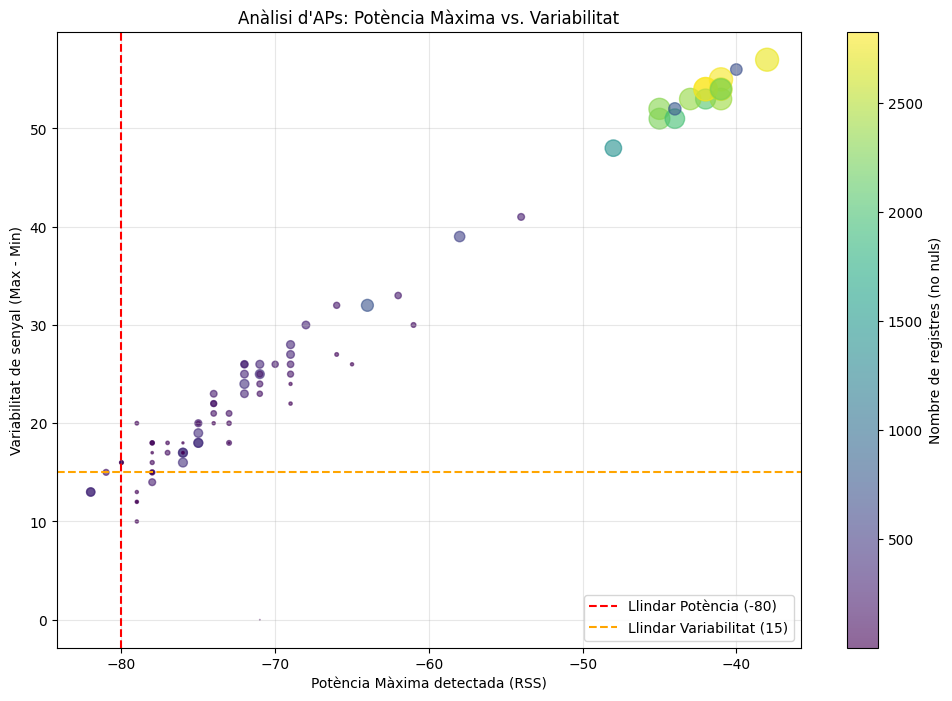

In [ ]:
# Transposar per tenir els APs a les files
df_filtre = min_max.T

# Calcular el rang (max - min)
df_filtre['rang'] = df_filtre['max'] - df_filtre['min']

# Comptar quants valors no són nulls per AP
df_filtre['comptador_non_null'] = df_train_2023_reduced_3.drop(columns='Pis').count()

# Definir els llindars
llindar_potencia_max = -80
llindar_rang = 15

# Gràfic
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_filtre['max'],
    df_filtre['rang'],
    c=df_filtre['comptador_non_null'],
    cmap='viridis',
    alpha=0.6,
    s=df_filtre['comptador_non_null'] / 10
)

# Afegir els llindars
plt.axvline(x=llindar_potencia_max, color='red', linestyle='--', label='Llindar Potència (-80)')
plt.axhline(y=llindar_rang, color='orange', linestyle='--', label='Llindar Variabilitat (15)')

plt.colorbar(scatter, label='Nombre de registres (no nuls)')
plt.title('Anàlisi d\'APs: Potència Màxima vs. Variabilitat')
plt.xlabel('Potència Màxima detectada (RSS)')
plt.ylabel('Variabilitat de senyal (Max - Min)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


*   **Quadrant Superior Dret:** APs amb senyal fort i molta variabilitat. Són els millors predictors.

*   **Zona Esquerra:** APs que tenen una potència màxima molt baixa. Solen ser punts de plantes llunyanes o altres edificis.

*   **Zona Inferior:** APs que tenen una baixa variabilitat. Si tenen pocs registres, són prescindibles.

*   **Color/Mida:** Com més groc i gran sigui el punt, més dades té aquell AP. Si un AP està situat a la zona "dolenta" i té molt pocs registres, és prescindible.

In [ ]:
# Aplicar el filtre
aps_bons = df_filtre[
    (df_filtre['rang'] >= llindar_rang) &
    (df_filtre['max'] > llindar_potencia_max)
].index

# Crear el DataFrame filtrat
df_train_2023_reduced_4 = df_train_2023_reduced_3[aps_bons.tolist() + ['Pis']]

print(f"Dimensions originals: {df_train_2023_reduced_3.shape[1]}")
print(f"Dimensions noves: {df_train_2023_reduced_4.shape[1]}")

Dimensions originals: 87
Dimensions noves: 74


## Experiments

A continuació, s'han elaborat una sèrie d'experiments utilitzant els models Random Forest i KNN.

### Experiment 1:

Utilitzar les dades sense tractar en el RF i KNN.

In [ ]:
"""
Eliminar la planta -1 del dataset
Màscares amb tots els registres que no són de la planta -1
per a filtrar el dataset de train i validació
"""
# Màscares
mascara_train = df_train_fl_2023[0] != -1
mascara_val = df_val_fl_2023[0] != -1

# Preparar les dades directament (sense resets ni copies explícites)
X_train = df_train_rss_2023[mascara_train].fillna(-105)
y_train = df_train_fl_2023[mascara_train].values.ravel()

X_val = df_val_rss_2023[mascara_val].fillna(-105)
y_val = df_val_fl_2023[mascara_val].values.ravel()

In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 310
Accuracy a Validació: 0.9636

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.9372    1.0000    0.9676       388
           0     1.0000    0.9202    0.9585       326

    accuracy                         0.9636       714
   macro avg     0.9686    0.9601    0.9630       714
weighted avg     0.9659    0.9636    0.9634       714



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 310
Accuracy a Validació: 0.8697

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.8214    0.9716    0.8902       388
           0     0.9569    0.7485    0.8399       326

    accuracy                         0.8697       714
   macro avg     0.8891    0.8601    0.8651       714
weighted avg     0.8832    0.8697    0.8672       714



### Experiment 2:
Conjunt reduït amb la reducció manual inicial.

In [ ]:
# Màscares
mascara_train = df_train_fl_2023[0] != -1
mascara_val = df_val_fl_2023[0] != -1

# Columnes finals
columnes_finals = df_train_2023_reduced_4.drop(columns=['Pis']).columns.tolist()

# Preparar les dades filtrades (sense planta -1)
X_train = df_train_rss_2023[columnes_finals][mascara_train].fillna(-105)
y_train = df_train_fl_2023[mascara_train].values.ravel()

X_val = df_val_rss_2023[columnes_finals][mascara_val].fillna(-105)
y_val = df_val_fl_2023[mascara_val].values.ravel()

In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 73
Accuracy a Validació: 0.9608

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.9390    0.9923    0.9649       388
           0     0.9901    0.9233    0.9556       326

    accuracy                         0.9608       714
   macro avg     0.9646    0.9578    0.9602       714
weighted avg     0.9624    0.9608    0.9606       714



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 73
Accuracy a Validació: 0.8950

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.8455    0.9871    0.9108       388
           0     0.9808    0.7853    0.8722       326

    accuracy                         0.8950       714
   macro avg     0.9132    0.8862    0.8915       714
weighted avg     0.9073    0.8950    0.8932       714



### Experiment 3:
Aplicar una reducció de dimensionalitat més agresiva.

In [ ]:
def aplicar_reduccio_agressiva(df, ap_cols, floor_col='Pis',
                               min_presencia=0.05,
                               min_variance=15.0,
                               top_n_per_floor=10,
                               quantile=0.75,
                               valor_nan=-105):
    """
    Aplica filtres de reducció de dimensionalitat per optimitzar el dataset d'APs.

    Paràmetres:
    - df: DataFrame original (NaN = AP no detectat).
    - ap_cols: Llista de columnes que són punts d'accés.
    - floor_col: Nom de la columna que indica la planta.
    - min_presencia: % mínim de registres on l'AP ha d'haver estat detectat (0.0 a 1.0).
    - min_variance: Llindar de variància.
    - top_n_per_floor: Número d'APs per cada planta.
    - quantile: Percentil per avaluar la representativitat de cada AP per planta (0.0 a 1.0).
    - valor_nan: Valor per substituir els NaN al DataFrame retornat.
    """

    print(f"--- Iniciant reducció: {len(ap_cols)} APs inicials ---")
    df_temp = df.copy()
    aps_actuals = list(ap_cols)

    # 1. FILTRE DE PRESÈNCIA
    # % de vegades que cada AP apareix
    presencia = df_temp[aps_actuals].notna().mean()
    # Aplicar filtre
    aps_actuals = presencia[presencia >= min_presencia].index.tolist()
    print(f"Pas 1 (Presència >= {min_presencia*100}%): Queden {len(aps_actuals)} APs")

    # 2. FILTRE DE VARIÀNCIA
    # Omplir NaN amb valor_nan per poder calcular la variància
    df_filled = df_temp[aps_actuals].fillna(valor_nan)
    # Elimina els AP amb poca variabilitat
    selector = VarianceThreshold(threshold=min_variance)
    selector.fit(df_filled)
    aps_actuals = [ap for ap, support in zip(aps_actuals, selector.get_support()) if support]
    print(f"Pas 2 (Variància >= {min_variance}): Queden {len(aps_actuals)} APs")

    # 3. FILTRE DE COBERTURA DE PLANTA
    millors_aps_per_planta = set()
    for planta in df_temp[floor_col].unique():
      # Agafar les dades de la planta
      df_planta = df_temp[df_temp[floor_col] == planta][aps_actuals]
      # Calcular el percentil per trobar les deteccions representatives
      representativitat = df_planta.quantile(quantile)
      # Eliminar APs que mai detectats en la planta
      representativitat = representativitat.dropna()
      # Agafar els més representatius
      n = min(top_n_per_floor, len(representativitat))
      top_aps = representativitat.nlargest(n).index.tolist()
      # Combinar els millors APs de les plantes
      millors_aps_per_planta.update(top_aps)

    aps_finals = list(millors_aps_per_planta)
    print(f"Pas 3 (Top {top_n_per_floor} APs per planta, percentil {quantile}): Queden {len(aps_finals)} APs totals")

    # Retornar el DataFrame amb les columnes seleccionades + llista dels APs seleccionats
    cols_no_ap = [c for c in df.columns if c not in ap_cols]
    df_resultat = df[cols_no_ap + aps_finals].copy()
    df_resultat[aps_finals] = df_resultat[aps_finals].fillna(valor_nan)

    return df_resultat, aps_finals

#### Experiment 3.1:

Reducció Moderada

In [ ]:
# Preparació de les dades
df_cons, aps_cons = aplicar_reduccio_agressiva(df_train_2023_reduced_4,
                                               df_train_2023_reduced_4.drop(columns=['Pis']).columns.tolist(),
                                               min_presencia=0.05,
                                               min_variance=15,
                                               top_n_per_floor=50)

# Màscares
mascara_train = df_train_fl_2023[0] != -1
mascara_val = df_val_fl_2023[0] != -1

# Preparar les dades filtrades (sense planta -1)
X_train = df_train_rss_2023[aps_cons][mascara_train].fillna(-105)
y_train = df_train_fl_2023[mascara_train].values.ravel()

X_val = df_val_rss_2023[aps_cons][mascara_val].fillna(-105)
y_val = df_val_fl_2023[mascara_val].values.ravel()

--- Iniciant reducció: 73 APs inicials ---
Pas 1 (Presència >= 5.0%): Queden 45 APs
Pas 2 (Variància >= 15): Queden 45 APs
Pas 3 (Top 50 APs per planta, percentil 0.75): Queden 45 APs totals


In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 45
Accuracy a Validació: 0.9454

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.9205    0.9845    0.9514       388
           0     0.9799    0.8988    0.9376       326

    accuracy                         0.9454       714
   macro avg     0.9502    0.9417    0.9445       714
weighted avg     0.9476    0.9454    0.9451       714



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 45
Accuracy a Validació: 0.9076

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.8643    0.9845    0.9205       388
           0     0.9779    0.8160    0.8896       326

    accuracy                         0.9076       714
   macro avg     0.9211    0.9002    0.9051       714
weighted avg     0.9162    0.9076    0.9064       714



#### Experiment 3.2:

Reducció Agresiva

In [ ]:
# Preparació de les dades
df_cons, aps_cons = aplicar_reduccio_agressiva(df_train_2023_reduced_4,
                                               df_train_2023_reduced_4.drop(columns=['Pis']).columns.tolist(),
                                               min_presencia=0.10,
                                               min_variance=20,
                                               top_n_per_floor=20)

# Màscares
mascara_train = df_train_fl_2023[0] != -1
mascara_val = df_val_fl_2023[0] != -1

# Preparar les dades filtrades (sense planta -1)
X_train = df_train_rss_2023[aps_cons][mascara_train].fillna(-105)
y_train = df_train_fl_2023[mascara_train].values.ravel()

X_val = df_val_rss_2023[aps_cons][mascara_val].fillna(-105)
y_val = df_val_fl_2023[mascara_val].values.ravel()

--- Iniciant reducció: 73 APs inicials ---
Pas 1 (Presència >= 10.0%): Queden 26 APs
Pas 2 (Variància >= 20): Queden 26 APs
Pas 3 (Top 20 APs per planta, percentil 0.75): Queden 26 APs totals


In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 26
Accuracy a Validació: 0.9342

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.9148    0.9691    0.9412       388
           0     0.9604    0.8926    0.9253       326

    accuracy                         0.9342       714
   macro avg     0.9376    0.9309    0.9332       714
weighted avg     0.9356    0.9342    0.9339       714



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 26
Accuracy a Validació: 0.8964

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.8504    0.9820    0.9115       388
           0     0.9737    0.7945    0.8750       326

    accuracy                         0.8964       714
   macro avg     0.9121    0.8882    0.8932       714
weighted avg     0.9067    0.8964    0.8948       714



### Experiment 4:

A partir del Random Forest del primer experiment, analitzar els punts d'accés més importants que el model determina.

El RF té la propietat feature_importances_ que diu quins APs considera que són més importants.

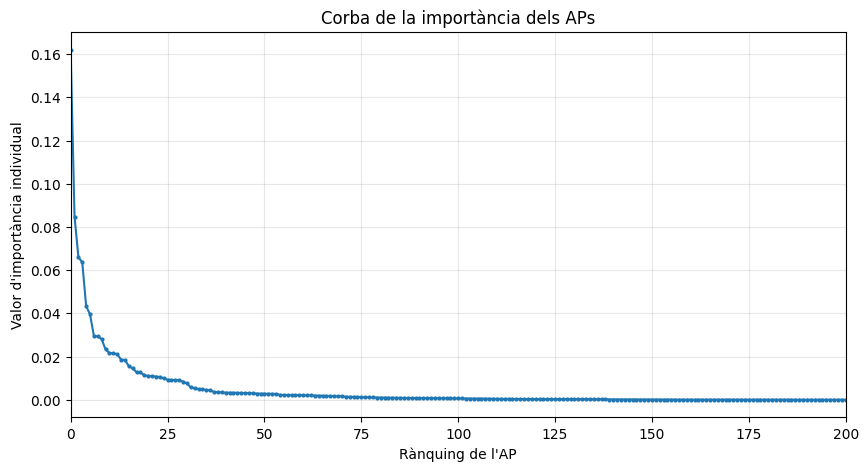

In [ ]:
# APs més importants
importances = model_rf.feature_importances_
noms_columnes = X_train.columns

# Crear un rànquing
importances_df = pd.DataFrame({'AP': noms_columnes, 'Importancia': importances})
data_sorted = importances_df.sort_values(by='Importancia', ascending=False)

# Visualitzar
plt.figure(figsize=(10, 5))
plt.plot(data_sorted['Importancia'].values, marker='o', markersize=2, linestyle='-')
plt.title('Corba de la importància dels APs')
plt.xlabel('Rànquing de l\'AP')
plt.ylabel('Valor d\'importància individual')
plt.grid(True, alpha=0.3)
plt.xlim(0, 200)
plt.show()

In [ ]:
# Màscares
mascara_train = df_train_fl_2023[0] != -1
mascara_val = df_val_fl_2023[0] != -1

# Preparació de les dades amb els millors APs trobats per RF
n_aps = 25
millors_aps = data_sorted.head(n_aps)['AP'].tolist()
X_train_top = df_train_rss_2023[millors_aps][mascara_train].fillna(-105)
y_train = df_train_fl_2023[mascara_train].values.ravel()

X_val_top = df_val_rss_2023[millors_aps][mascara_val]
y_val = df_val_fl_2023[mascara_val].values.ravel()

In [ ]:
# Random Forest
model_rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_final.fit(X_train_top, y_train)

# Validar
preds = model_rf_final.predict(X_val_top)

# Avaluació resultats
print(f"Nombre d'APs utilitzats: {X_train_top.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds, digits=4))

Nombre d'APs utilitzats: 25
Accuracy a Validació: 0.9370

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.9113    0.9794    0.9441       388
           0     0.9731    0.8865    0.9278       326

    accuracy                         0.9370       714
   macro avg     0.9422    0.9329    0.9359       714
weighted avg     0.9395    0.9370    0.9366       714



### Avaluació final

Utilitzant el model Random Forest de l'experiment 2 amb 73 APs.

In [ ]:
# Màscara
mascara_test = df_test_fl_2023.iloc[:, 4] != -1

# Preparació de les dades
X_test = df_test_rss_2023[columnes_finals][mascara_test].fillna(-105)
y_test = df_test_fl_2023.iloc[:, 4][mascara_test].values

preds_test = model_rf.predict(X_test)
print(f"Accuracy a Test: {accuracy_score(y_test, preds_test):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_test, preds_test, digits=4))

Accuracy a Test: 0.8485

Informe de Classificació:
              precision    recall  f1-score   support

          -2     0.7907    0.9714    0.8718        70
           0     0.9565    0.7097    0.8148        62

    accuracy                         0.8485       132
   macro avg     0.8736    0.8406    0.8433       132
weighted avg     0.8686    0.8485    0.8450       132

